In [1]:
# Notebook path bootstrap for moved files
import os
import sys
import re
import json
import pickle
import numpy as np

def find_project_root(start_dir):
    cur = os.path.abspath(start_dir)
    while True:
        if os.path.isdir(os.path.join(cur, 'figs-submit')):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            raise FileNotFoundError('Could not find project root containing figs-submit.')
        cur = parent

PROJECT_ROOT = find_project_root(os.getcwd())
os.chdir(PROJECT_ROOT)
FIGS_SUBMIT_DIR = os.path.join(PROJECT_ROOT, 'figs-submit')
UTILS_DIR = os.path.join(FIGS_SUBMIT_DIR, 'utils')
if FIGS_SUBMIT_DIR not in sys.path:
    sys.path.insert(0, FIGS_SUBMIT_DIR)
if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

print('PROJECT_ROOT =', PROJECT_ROOT)

# Minimal helpers kept for Step8 plotting
POS_COLORS = ['#440154', '#414487', '#2a788e', '#22a884', '#7ad151', '#fde725']

def _pos_color(index, offset=0):
    color_index = int(index) + int(offset)
    color_index = max(0, min(color_index, len(POS_COLORS) - 1))
    return POS_COLORS[color_index]

def format_p(p):
    if p < 0.001:
        return 'p < 0.001'
    elif p < 0.01:
        return 'p < 0.01'
    elif p < 0.05:
        return 'p < 0.05'
    else:
        return f'p = {p:.2f}'

def _normalized_regulariy_axis(n_bins):
    if n_bins <= 1:
        return np.array([0.0], dtype=float)
    return np.linspace(0.0, 1.0, n_bins, dtype=float)

def _enforce_line_axes_box_aspect(fig, width_mm=76.1, height_mm=61.5):
    return

_model_ = '1000, yy'
_MODEL_TAG = re.sub(r'[^A-Za-z0-9_.-]+', '_', _model_).strip('_')
CACHE_OUT_DIR = os.path.join('cache', 'resonance', _MODEL_TAG)
os.makedirs(CACHE_OUT_DIR, exist_ok=True)
out_dir = os.path.join('figs', 'resonance')
os.makedirs(out_dir, exist_ok=True)

def save_intermediate_pickle(data, filename):
    out_path = os.path.join(CACHE_OUT_DIR, filename)
    with open(out_path, 'wb') as f:
        pickle.dump(data, f)
    print(f'[cache] saved: {out_path}')

def _load_cached_pickle(filename_candidates):
    for fn in filename_candidates:
        p = os.path.join(CACHE_OUT_DIR, fn)
        if os.path.exists(p):
            with open(p, 'rb') as f:
                print(f'[cache] loaded: {p}')
                return pickle.load(f)
    tried = '\n  - '.join(os.path.join(CACHE_OUT_DIR, fn) for fn in filename_candidates)
    raise FileNotFoundError(
        'Required cache files not found. Please run Fig3 notebook first to generate step45/step6 caches.\n  - ' + tried
    )  

step45_change0 = _load_cached_pickle(['step45_change0.pkl'])
step6_change0 = _load_cached_pickle(['step6_change0_onset_specific_prc.pkl', 'step6_change0_pooled_prc.pkl'])


PROJECT_ROOT = /home/yangqizhi/Projects/Rhythm
[cache] loaded: cache/resonance/1000_yy/step45_change0.pkl
[cache] loaded: cache/resonance/1000_yy/step6_change0_onset_specific_prc.pkl


Fig4AB



[Step8 debug summary]
f0_hz                   = 2.500
amp_floor               = 1.306785
amp_ref                 = 2.883140
min_valid_lock_points   = 6
Example low-R trial     = 1398 (R=0.571)
Example R=1 trial       = 280 (R=1.000)
IOI1: mean lock = 0.974, median lock = 0.980, mean lag = -93.48 deg
    valid frac = 0.659 ± 0.284 | eff weight frac = 0.422 ± 0.260
IOI2: mean lock = 0.903, median lock = 0.955, mean lag = -99.58 deg
    valid frac = 0.815 ± 0.205 | eff weight frac = 0.521 ± 0.220
IOI3: mean lock = 0.908, median lock = 0.954, mean lag = -95.34 deg
    valid frac = 0.778 ± 0.232 | eff weight frac = 0.499 ± 0.227
IOI4: mean lock = 0.910, median lock = 0.949, mean lag = -99.20 deg
    valid frac = 0.823 ± 0.209 | eff weight frac = 0.566 ± 0.229
IOI5: mean lock = 0.916, median lock = 0.953, mean lag = -118.49 deg
    valid frac = 0.869 ± 0.183 | eff weight frac = 0.640 ± 0.227
Sequence-level mean lock: valid n = 2000, mean = 0.921, median = 0.950
Sequence-level Spearman: ρ = 

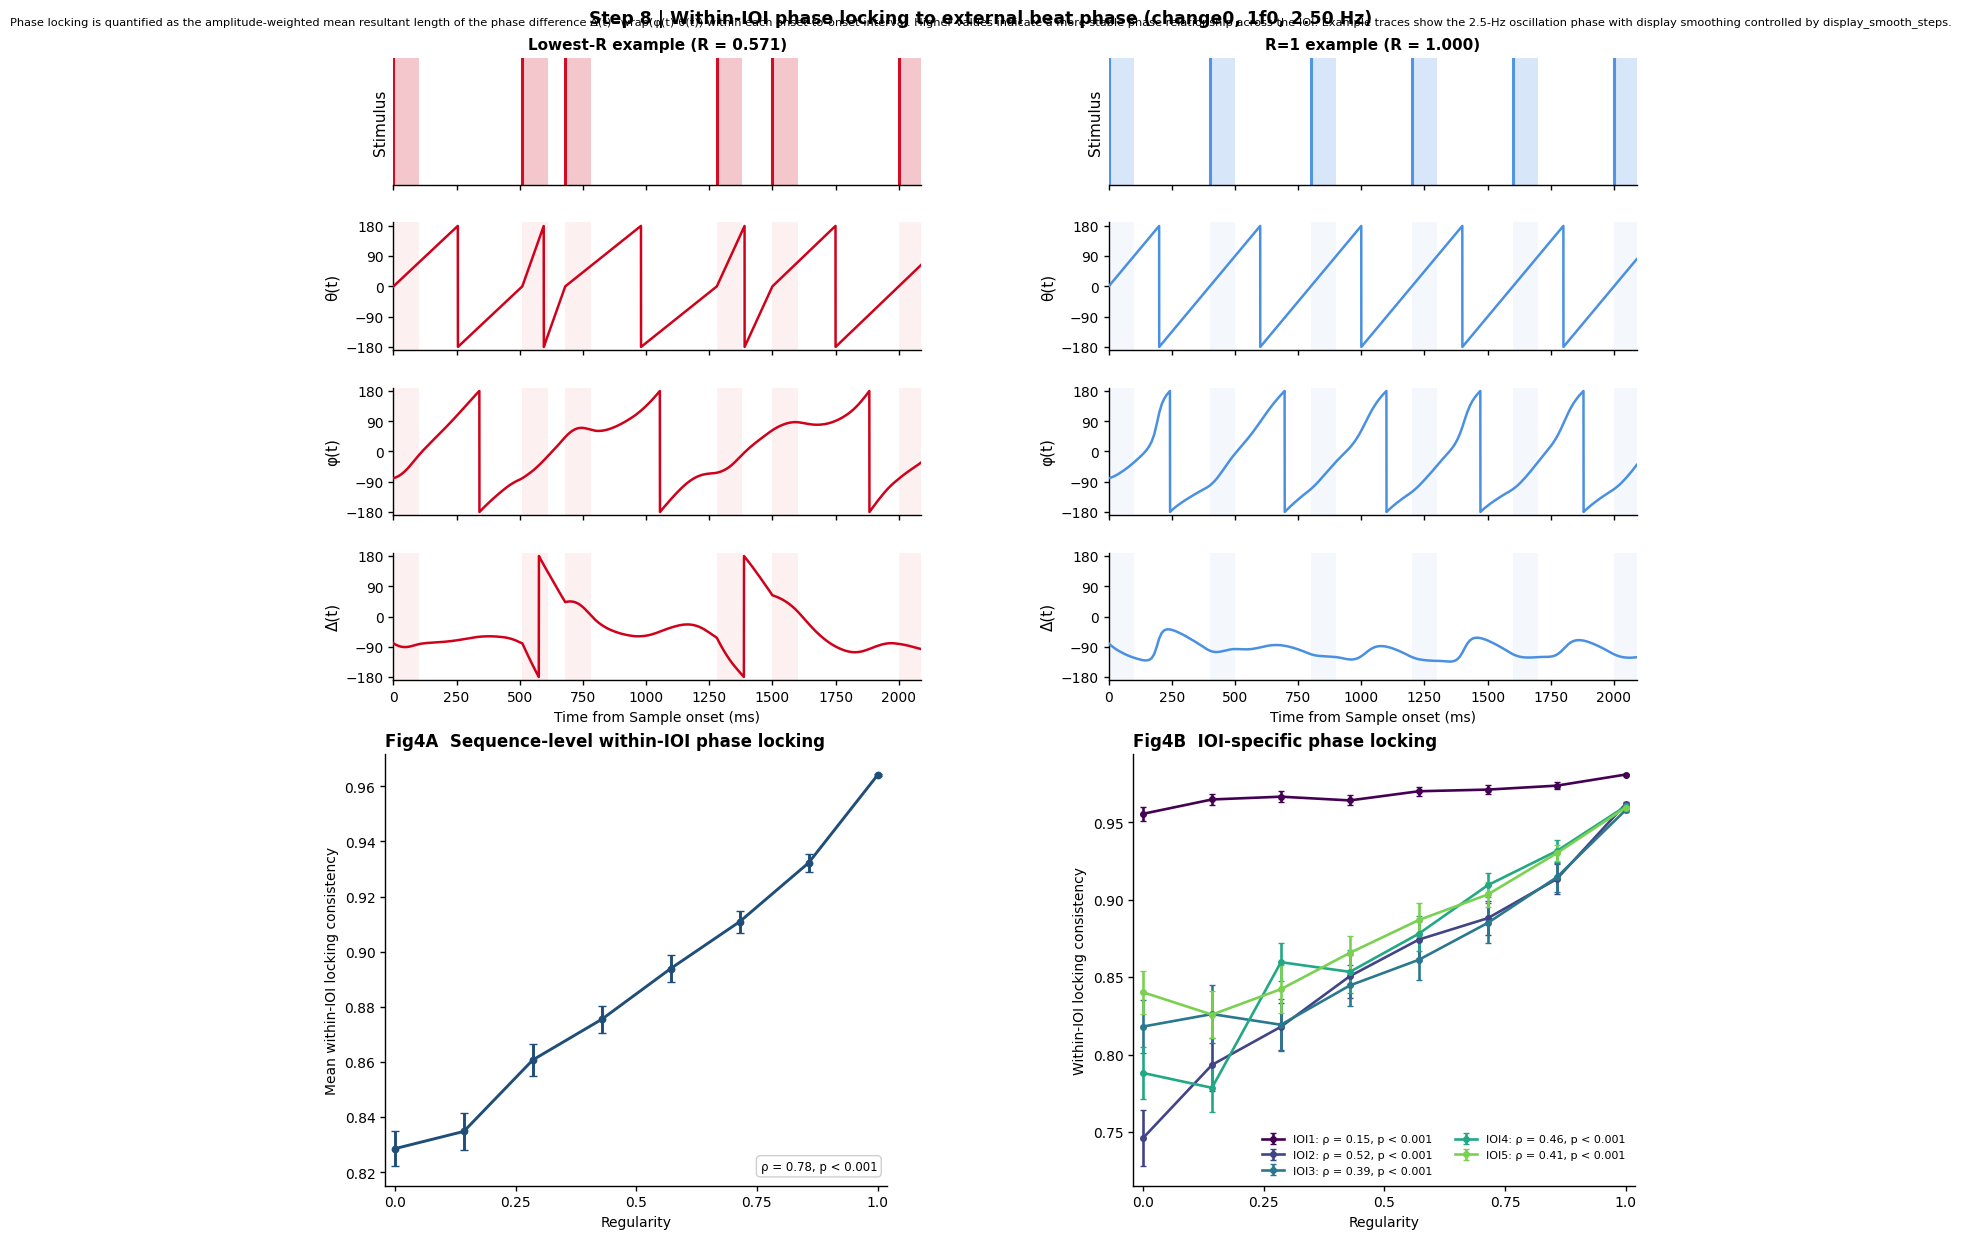

In [2]:
# ========================================================================
# Part 9: Step 8 | Within-IOI phase locking to external beat phase
# ========================================================================
# =========================================================
# Step 8 | Within-IOI phase locking to external beat phase
# Final version with continuous wrap-bridge display
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================================================
# 0) Style helper
# =========================================================
def _step8_set_style():
    fn = globals().get("set_nature_neuro_style", None)
    if callable(fn):
        fn()
    else:
        plt.rcParams.update({
            "font.size": 10,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.linewidth": 1.0,
            "xtick.major.width": 1.0,
            "ytick.major.width": 1.0,
        })

# =========================================================
# 1) Generic helpers
# =========================================================
def _step8_wrap_deg(x):
    x = np.asarray(x, dtype=float)
    return ((x + 180.0) % 360.0) - 180.0

def _step8_wrap_rad(x):
    x = np.asarray(x, dtype=float)
    return np.deg2rad(_step8_wrap_deg(np.rad2deg(x)))

def _step8_nansem(x, axis=0):
    x = np.asarray(x, dtype=float)
    n = np.sum(np.isfinite(x), axis=axis)
    sd = np.nanstd(x, axis=axis, ddof=1)
    out = sd / np.sqrt(np.maximum(n, 1))
    out = np.asarray(out)
    out[n <= 1] = np.nan
    return out

def _step8_safe_row_nanmean(x):
    x = np.asarray(x, dtype=float)
    out = np.full(x.shape[0], np.nan, dtype=float)
    valid_counts = np.sum(np.isfinite(x), axis=1)
    has_valid = valid_counts > 0
    if np.any(has_valid):
        out[has_valid] = np.nanmean(x[has_valid], axis=1)
    return out

def _step8_bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out = np.full(pvals.shape, np.nan, dtype=float)

    valid = np.isfinite(pvals)
    if not np.any(valid):
        return out

    pv = pvals[valid]
    n = len(pv)
    order = np.argsort(pv)
    ranked = pv[order]

    qvals_ranked = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        q = ranked[i] * n / rank
        prev = min(prev, q)
        qvals_ranked[i] = prev

    qvals = np.empty(n, dtype=float)
    qvals[order] = np.clip(qvals_ranked, 0.0, 1.0)
    out[valid] = qvals
    return out

# =========================================================
# 2) Step6-consistent amplitude weights
# =========================================================
def _step8_amp_weights(amp_vals, amp_floor, amp_ref):
    amp_vals = np.asarray(amp_vals, dtype=float)
    w = np.zeros_like(amp_vals, dtype=float)
    valid = np.isfinite(amp_vals)
    if np.any(valid):
        rel = (amp_vals[valid] - amp_floor) / (amp_ref - amp_floor + 1e-12)
        rel = np.clip(rel, 0.0, 1.0)
        w[valid] = np.sqrt(rel)
    return w

def _step8_weighted_resultant(delta_rad, w, min_valid_points=6):
    """
    Weighted circular consistency over time within one IOI.
    """
    delta_rad = np.asarray(delta_rad, dtype=float)
    w = np.asarray(w, dtype=float)

    valid = np.isfinite(delta_rad) & np.isfinite(w) & (w > 0)
    L = len(delta_rad)
    if L == 0:
        return np.nan, np.nan, np.nan, np.nan
    if np.sum(valid) < min_valid_points:
        return np.nan, np.nan, np.mean(valid), np.sum(w[valid]) / max(L, 1)

    z = np.sum(w[valid] * np.exp(1j * delta_rad[valid]))
    sw = np.sum(w[valid])
    if sw <= 0:
        return np.nan, np.nan, np.mean(valid), 0.0

    lock = np.abs(z) / sw
    lag_deg = _step8_wrap_deg(np.rad2deg(np.angle(z)))
    valid_frac = np.mean(valid)
    eff_weight_frac = sw / max(L, 1)
    return float(lock), float(lag_deg), float(valid_frac), float(eff_weight_frac)

# =========================================================
# 3) Display smoothing helpers (DISPLAY ONLY)
# =========================================================
def _step8_moving_average_linear(x, win):
    """
    Linear moving average with edge padding.
    For unwrapped phase display only.
    """
    x = np.asarray(x, dtype=float)
    if win is None or win <= 1:
        return x.copy()

    win = int(win)
    if win % 2 == 0:
        win += 1

    pad = win // 2
    xp = np.pad(x, pad_width=pad, mode="edge")
    ker = np.ones(win, dtype=float) / float(win)
    ys = np.convolve(xp, ker, mode="valid")
    return ys

def _step8_moving_average_circular_deg(x_deg, win):
    """
    Circular moving average for wrapped angles in degrees.
    For Δ(t) display only.
    """
    x_deg = np.asarray(x_deg, dtype=float)
    if win is None or win <= 1:
        return x_deg.copy()

    win = int(win)
    if win % 2 == 0:
        win += 1

    pad = win // 2
    ang = np.deg2rad(x_deg)
    z = np.exp(1j * ang)

    zp_real = np.pad(np.real(z), pad_width=pad, mode="edge")
    zp_imag = np.pad(np.imag(z), pad_width=pad, mode="edge")

    ker = np.ones(win, dtype=float) / float(win)
    zs_real = np.convolve(zp_real, ker, mode="valid")
    zs_imag = np.convolve(zp_imag, ker, mode="valid")
    zs = zs_real + 1j * zs_imag

    return _step8_wrap_deg(np.rad2deg(np.angle(zs)))

# =========================================================
# 4) Example-trial helpers
# =========================================================
def _step8_pick_representative_trial(indices, seq_metric):
    indices = np.asarray(indices, dtype=int)
    if len(indices) == 0:
        return None

    vals = np.asarray(seq_metric[indices], dtype=float)
    finite = np.isfinite(vals)
    if not np.any(finite):
        return int(indices[0])

    idx_f = indices[finite]
    vals_f = vals[finite]
    med = np.nanmedian(vals_f)
    return int(idx_f[np.argmin(np.abs(vals_f - med))])

def _step8_pick_example_trials(r_raw, seq_lock_mean):
    r_raw = np.asarray(r_raw, dtype=float)
    seq_lock_mean = np.asarray(seq_lock_mean, dtype=float)

    rmin = np.nanmin(r_raw)
    idx_low = np.where(np.isclose(r_raw, rmin, atol=1e-12))[0]
    trial_low = _step8_pick_representative_trial(idx_low, seq_lock_mean)

    idx_r1 = np.where(np.isclose(r_raw, 1.0, atol=1e-12))[0]
    if len(idx_r1) > 0:
        trial_r1 = _step8_pick_representative_trial(idx_r1, seq_lock_mean)
    else:
        rmax = np.nanmax(r_raw)
        idx_r1 = np.where(np.isclose(r_raw, rmax, atol=1e-12))[0]
        trial_r1 = _step8_pick_representative_trial(idx_r1, seq_lock_mean)

    return int(trial_low), int(trial_r1)
 
def _step8_build_external_phase_ioi_deg(L):
    """
    External beat phase within one IOI:
      0, 360/L, ..., (L-1)*360/L
    wrapped to [-180, 180)
    """
    if L <= 0:
        return np.array([], dtype=float)
    return _step8_wrap_deg(360.0 * np.arange(L, dtype=float) / float(L))

def _step8_build_example_display_arrays(
    phase_u_signed_trial,
    onsets_trial,
    stim_dur_steps,
    fs,
    display_smooth_steps=1,
):
    """
    Build display arrays for one sample-stage example trial.

    display_smooth_steps affects ONLY the example traces:
      - φ(t): smooth unwrapped phase linearly, then wrap back
      - Δ(t): smooth circularly after computing wrapped difference
      - θ(t): kept unsmoothed
    """
    phase_u_signed_trial = np.asarray(phase_u_signed_trial, dtype=float)
    onsets_trial = np.asarray(onsets_trial, dtype=int)

    sample_start = int(onsets_trial[0])
    sample_end = int(min(len(phase_u_signed_trial), onsets_trial[-1] + stim_dur_steps))

    n_disp = sample_end - sample_start
    time_ms = np.arange(n_disp, dtype=float) * (1000.0 / fs)

    # internal phase display: smooth unwrapped phase for DISPLAY ONLY
    phi_unwrapped_deg = np.rad2deg(phase_u_signed_trial[sample_start:sample_end])
    phi_unwrapped_deg_disp = _step8_moving_average_linear(phi_unwrapped_deg, display_smooth_steps)
    phi_deg = _step8_wrap_deg(phi_unwrapped_deg_disp)

    # external phase display
    theta_deg = np.full(n_disp, np.nan, dtype=float)

    n_onset = len(onsets_trial)
    n_ioi = n_onset - 1

    for j in range(n_ioi):
        s = int(onsets_trial[j] - sample_start)
        e = int(onsets_trial[j + 1] - sample_start)
        L = e - s
        if L <= 0:
            continue
        theta_deg[s:e] = _step8_build_external_phase_ioi_deg(L)

    # extend a final partial cycle during Stim6 for display only
    if n_ioi >= 1:
        s_last = int(onsets_trial[-1] - sample_start)
        e_last = n_disp
        L_tail = e_last - s_last
        L_ref = int(onsets_trial[-1] - onsets_trial[-2])
        if L_tail > 0 and L_ref > 0:
            theta_deg[s_last:e_last] = _step8_wrap_deg(
                360.0 * np.arange(L_tail, dtype=float) / float(L_ref)
            )

    delta_deg_raw = _step8_wrap_deg(phi_deg - theta_deg)
    delta_deg = _step8_moving_average_circular_deg(delta_deg_raw, display_smooth_steps)

    stim_spans_ms = []
    for t_on in onsets_trial:
        s = (int(t_on) - sample_start) * (1000.0 / fs)
        e = (int(t_on) - sample_start + stim_dur_steps) * (1000.0 / fs)
        stim_spans_ms.append((s, e))

    return {
        "time_ms": time_ms,
        "theta_deg": theta_deg,
        "phi_deg": phi_deg,
        "delta_deg": delta_deg,
        "stim_spans_ms": stim_spans_ms,
    }

# =========================================================
# 5) Continuous wrapped plotting helper with bridge
# =========================================================
def _step8_plot_continuous_wrapped_trace(
    ax,
    x,
    y,
    color="#5B8BD6",
    lw=1.8,
    ms=1.5,
    show_markers=False,
    wrap_bridge_frac=0.08,
    zorder=3,
):
    """
    Plot a wrapped angular trace continuously across the [-180, 180) boundary.

    At boundary crossings, a short bridge segment is inserted so the trace
    stays continuous rather than broken or vertical.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    idx = np.where(valid)[0]
    if len(idx) < 2:
        if len(idx) == 1 and show_markers:
            ax.plot(x[idx], y[idx], linestyle="None", marker="o", ms=ms, color=color, zorder=zorder)
        return

    plot_x = []
    plot_y = []

    def _append_nan():
        if len(plot_x) > 0:
            plot_x.append(np.nan)
            plot_y.append(np.nan)

    for n, (k0, k1) in enumerate(zip(idx[:-1], idx[1:])):
        # only connect consecutive time samples
        if k1 != k0 + 1:
            _append_nan()
            continue

        x0, x1 = x[k0], x[k1]
        y0, y1 = y[k0], y[k1]

        d = float(_step8_wrap_deg(y1 - y0))
        target = y0 + d

        if n == 0:
            plot_x.append(x0)
            plot_y.append(y0)

        # no boundary crossing
        if -180.0 <= target < 180.0:
            plot_x.append(x1)
            plot_y.append(target)
            continue

        # boundary crossing: add a short bridge around crossing
        dx = x1 - x0
        eps = min(abs(dx) * wrap_bridge_frac, abs(dx) * 0.45)

        if target >= 180.0:
            alpha = (180.0 - y0) / d
            x_cross = x0 + alpha * dx
            xb1 = max(x0, x_cross - eps / 2.0)
            xb2 = min(x1, x_cross + eps / 2.0)

            # pre-boundary point
            yb1 = y0 + d * ((xb1 - x0) / dx)
            plot_x.extend([xb1, xb2, x1])
            plot_y.extend([yb1, -180.0, -180.0 + (target - 180.0)])

        elif target < -180.0:
            alpha = (-180.0 - y0) / d
            x_cross = x0 + alpha * dx
            xb1 = max(x0, x_cross - eps / 2.0)
            xb2 = min(x1, x_cross + eps / 2.0)

            yb1 = y0 + d * ((xb1 - x0) / dx)
            plot_x.extend([xb1, xb2, x1])
            plot_y.extend([yb1, 180.0, 180.0 + (target + 180.0)])

    ax.plot(plot_x, plot_y, color=color, lw=lw, zorder=zorder)

    if show_markers:
        ax.plot(
            x[idx], y[idx],
            linestyle="None",
            marker="o",
            ms=ms,
            mec=color,
            mfc=color,
            color=color,
            zorder=zorder + 0.1,
        )

# =========================================================
# 6) Debug summary
# =========================================================
def print_step8_debug_summary(step8_results):
    print("\n[Step8 debug summary]")
    print(f"f0_hz                   = {step8_results['f0_hz']:.3f}")
    print(f"amp_floor               = {step8_results['amp_floor']:.6f}")
    print(f"amp_ref                 = {step8_results['amp_ref']:.6f}")
    print(f"min_valid_lock_points   = {step8_results['min_valid_lock_points']}")

    print(f"Example low-R trial     = {step8_results['example_low_r_trial']} (R={step8_results['example_low_r_value']:.3f})")
    print(f"Example R=1 trial       = {step8_results['example_r1_trial']} (R={step8_results['example_r1_value']:.3f})")

    for j, lab in enumerate(step8_results["ioi_labels"]):
        vals_lock = step8_results["lock_mrl"][:, j]
        vals_lag = step8_results["lag_deg"][:, j]
        vals_v = step8_results["lock_valid_frac"][:, j]
        vals_w = step8_results["lock_eff_weight_frac"][:, j]
        print(
            f"{lab}: "
            f"mean lock = {np.nanmean(vals_lock):.3f}, "
            f"median lock = {np.nanmedian(vals_lock):.3f}, "
            f"mean lag = {np.nanmean(vals_lag):.2f} deg"
        )
        print(
            f"    valid frac = {np.nanmean(vals_v):.3f} ± {np.nanstd(vals_v):.3f} | "
            f"eff weight frac = {np.nanmean(vals_w):.3f} ± {np.nanstd(vals_w):.3f}"
        )

    seq_vals = step8_results["seq_lock_mean"]
    print(
        f"Sequence-level mean lock: "
        f"valid n = {np.sum(np.isfinite(seq_vals))}, "
        f"mean = {np.nanmean(seq_vals):.3f}, median = {np.nanmedian(seq_vals):.3f}"
    )
    print(
        f"Sequence-level Spearman: ρ = {step8_results['seq_lock_rho']:.2f}, "
        f"p = {step8_results['seq_lock_p']:.2e}"
    )

# =========================================================
# 7) Main Step8 analysis
# =========================================================
def analyze_step8(
    step45_results,
    step6_results,
    min_valid_lock_points=None,
    expected_f0_hz=2.5,
    print_debug_summary=True,
):
    phase_ts = np.asarray(step45_results["phase_ts"], dtype=float)
    amp_ts = np.asarray(step45_results["amp_ts"], dtype=float)
    onsets_sel = np.asarray(step45_results["onsets_sel"], dtype=int)

    fs = float(step45_results["fs"])
    stim_dur_steps = int(step45_results["stim_dur_steps"])
    r_raw = np.asarray(step45_results["r_raw"], dtype=float)
    r_bin_index = np.asarray(step45_results["r_bin_index"], dtype=int)
    bin_medians_raw = np.asarray(step45_results["bin_medians_raw"], dtype=float)
    band_info = step45_results["band_info"]

    n_trial, n_time = phase_ts.shape
    n_onset = onsets_sel.shape[1]
    n_ioi = n_onset - 1
    n_bins = len(bin_medians_raw)

    if "phase_u_signed" in step6_results:
        phase_u_signed = np.asarray(step6_results["phase_u_signed"], dtype=float)
    else:
        phase_forward_sign = float(step6_results.get("phase_forward_sign", 1.0))
        phase_u_signed = np.unwrap(phase_ts, axis=-1) * phase_forward_sign

    f0_hz = float(step6_results.get("f0_hz", band_info["center_hz"]))
    if not np.isclose(f0_hz, expected_f0_hz, atol=1e-6):
        print(f"[Step8 warning] f0_hz = {f0_hz:.6f}, not exactly expected {expected_f0_hz:.6f} Hz.")

    amp_floor = float(step6_results["amp_floor"])
    amp_ref = float(step6_results["amp_ref"])

    if min_valid_lock_points is None:
        min_valid_lock_points = int(step6_results["min_valid_stim_points"])

    ioi_len_steps = np.full((n_trial, n_ioi), np.nan, dtype=float)
    lock_mrl = np.full((n_trial, n_ioi), np.nan, dtype=float)
    lag_deg = np.full((n_trial, n_ioi), np.nan, dtype=float)
    lock_valid_frac = np.full((n_trial, n_ioi), np.nan, dtype=float)
    lock_eff_weight_frac = np.full((n_trial, n_ioi), np.nan, dtype=float)

    for tr in range(n_trial):
        for j in range(n_ioi):
            t0 = int(onsets_sel[tr, j])
            t1 = int(onsets_sel[tr, j + 1])

            L = t1 - t0
            if L < 2:
                continue
            if not (0 <= t0 < n_time and 0 < t1 <= n_time and t1 > t0):
                continue

            idx = np.arange(t0, t1, dtype=int)
            phi_rad = phase_u_signed[tr, idx]
            theta_deg = _step8_build_external_phase_ioi_deg(L)
            theta_rad = np.deg2rad(theta_deg)

            delta_rad = _step8_wrap_rad(phi_rad - theta_rad)
            w = _step8_amp_weights(amp_ts[tr, idx], amp_floor=amp_floor, amp_ref=amp_ref)

            lock, lag, valid_frac, eff_weight_frac = _step8_weighted_resultant(
                delta_rad=delta_rad,
                w=w,
                min_valid_points=min_valid_lock_points,
            )

            ioi_len_steps[tr, j] = L
            lock_mrl[tr, j] = lock
            lag_deg[tr, j] = lag
            lock_valid_frac[tr, j] = valid_frac
            lock_eff_weight_frac[tr, j] = eff_weight_frac

    seq_lock_mean = _step8_safe_row_nanmean(lock_mrl)

    seq_lock_bin_mean = np.full(n_bins, np.nan, dtype=float)
    seq_lock_bin_sem = np.full(n_bins, np.nan, dtype=float)
    seq_lock_bin_n = np.zeros(n_bins, dtype=int)

    ioi_lock_bin_mean = np.full((n_bins, n_ioi), np.nan, dtype=float)
    ioi_lock_bin_sem = np.full((n_bins, n_ioi), np.nan, dtype=float)
    ioi_lock_bin_n = np.zeros((n_bins, n_ioi), dtype=int)

    for b in range(n_bins):
        idx_b = np.where(r_bin_index == b)[0]

        vals_seq = seq_lock_mean[idx_b]
        vals_seq = vals_seq[np.isfinite(vals_seq)]
        seq_lock_bin_n[b] = len(vals_seq)
        if len(vals_seq) > 0:
            seq_lock_bin_mean[b] = np.mean(vals_seq)
            seq_lock_bin_sem[b] = stats.sem(vals_seq, nan_policy="omit") if len(vals_seq) > 1 else 0.0

        for j in range(n_ioi):
            vals = lock_mrl[idx_b, j]
            vals = vals[np.isfinite(vals)]
            ioi_lock_bin_n[b, j] = len(vals)
            if len(vals) > 0:
                ioi_lock_bin_mean[b, j] = np.mean(vals)
                ioi_lock_bin_sem[b, j] = stats.sem(vals, nan_policy="omit") if len(vals) > 1 else 0.0

    valid_seq = np.isfinite(r_raw) & np.isfinite(seq_lock_mean)
    if np.sum(valid_seq) >= 5:
        rr_seq = stats.spearmanr(r_raw[valid_seq], seq_lock_mean[valid_seq])
        seq_lock_rho = rr_seq.correlation
        seq_lock_p = rr_seq.pvalue
    else:
        seq_lock_rho, seq_lock_p = np.nan, np.nan

    ioi_lock_rho = np.full(n_ioi, np.nan)
    ioi_lock_p = np.full(n_ioi, np.nan)

    for j in range(n_ioi):
        valid = np.isfinite(r_raw) & np.isfinite(lock_mrl[:, j])
        if np.sum(valid) >= 5:
            rr = stats.spearmanr(r_raw[valid], lock_mrl[valid, j])
            ioi_lock_rho[j] = rr.correlation
            ioi_lock_p[j] = rr.pvalue

    ioi_lock_q = _step8_bh_fdr(ioi_lock_p)

    example_low_r_trial, example_r1_trial = _step8_pick_example_trials(r_raw, seq_lock_mean)

    results = {
        "fs": fs,
        "stim_dur_steps": stim_dur_steps,
        "band_info": band_info,
        "f0_hz": f0_hz,
        "r_raw": r_raw,
        "r_bin_index": r_bin_index,
        "bin_medians_raw": bin_medians_raw,

        "phase_u_signed": phase_u_signed,
        "amp_floor": amp_floor,
        "amp_ref": amp_ref,
        "min_valid_lock_points": min_valid_lock_points,

        "ioi_labels": [f"IOI{j+1}" for j in range(n_ioi)],
        "ioi_len_steps": ioi_len_steps,
        "lock_mrl": lock_mrl,
        "lag_deg": lag_deg,
        "lock_valid_frac": lock_valid_frac,
        "lock_eff_weight_frac": lock_eff_weight_frac,

        "seq_lock_mean": seq_lock_mean,

        "seq_lock_bin_mean": seq_lock_bin_mean,
        "seq_lock_bin_sem": seq_lock_bin_sem,
        "seq_lock_bin_n": seq_lock_bin_n,

        "ioi_lock_bin_mean": ioi_lock_bin_mean,
        "ioi_lock_bin_sem": ioi_lock_bin_sem,
        "ioi_lock_bin_n": ioi_lock_bin_n,

        "seq_lock_rho": seq_lock_rho,
        "seq_lock_p": seq_lock_p,
        "ioi_lock_rho": ioi_lock_rho,
        "ioi_lock_p": ioi_lock_p,
        "ioi_lock_q": ioi_lock_q,

        "example_low_r_trial": example_low_r_trial,
        "example_low_r_value": float(r_raw[example_low_r_trial]),
        "example_r1_trial": example_r1_trial,
        "example_r1_value": float(r_raw[example_r1_trial]),
    }

    if print_debug_summary:
        print_step8_debug_summary(results)

    return results

# =========================================================
# 8) Main plotting function
# =========================================================
def plot_step8_main(
    step8_results,
    step45_results,
    layer_name="layer",
    figsize=(13.2, 12),
    display_smooth_steps=3,
    show_display_markers=False,
    wrap_bridge_frac=0.08,
    save_pdf_path=None,
):
    """
    display_smooth_steps
    --------------------
    Controls ONLY the example traces in Panel A.
      1 = raw display
      3 / 5 = progressively smoother display

    wrap_bridge_frac
    ----------------
    Controls the horizontal width of the continuous bridge at wrap crossings.
    Larger values make the boundary transition appear smoother.
    """
    _step8_set_style()

    band_info = step8_results["band_info"]
    fs = step8_results["fs"]
    stim_dur_steps = step8_results["stim_dur_steps"]
    onsets_sel = np.asarray(step45_results["onsets_sel"], dtype=int)

    x_labels = step8_results["bin_medians_raw"]
    n_bins = len(step8_results["bin_medians_raw"])
    x_pos = _normalized_regulariy_axis(n_bins)
    x_tick_pos = np.linspace(0.0, 1.0, 5)
    x_tick_labels = ["0.00", "0.25", "0.50", "0.75", "1.00"]

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    outer = fig.add_gridspec(2, 1, height_ratios=[2.75, 2], hspace=0.32)

    top = outer[0].subgridspec(4, 2, hspace=0.10, wspace=0.18)
    bottom = outer[1].subgridspec(1, 2, wspace=0.28)

    ex_trials = [
        step8_results["example_low_r_trial"],
        step8_results["example_r1_trial"],
    ]
    ex_titles = [
        f"Lowest-R example (R = {step8_results['example_low_r_value']:.3f})",
        f"R=1 example (R = {step8_results['example_r1_value']:.3f})",
    ]

    row_labels = ["Stimulus", "θ(t)", "φ(t)", "Δ(t)"]

    # low-R column = red, R=1 column = blue
    example_colors = [
        "#D0021B",  # lowest-R example
        "#4A90E2",  # R=1 example
    ]

    for c, tr in enumerate(ex_trials):
        phase_color = example_colors[c]

        # make row-1 stimulus use the SAME column color
        stim_fill_col = phase_color
        stim_line_col = phase_color

        disp = _step8_build_example_display_arrays(
            phase_u_signed_trial=step8_results["phase_u_signed"][tr],
            onsets_trial=onsets_sel[tr],
            stim_dur_steps=stim_dur_steps,
            fs=fs,
            display_smooth_steps=display_smooth_steps,
        )

        time_ms = disp["time_ms"]
        theta_deg = disp["theta_deg"]
        phi_deg = disp["phi_deg"]
        delta_deg = disp["delta_deg"]
        stim_spans_ms = disp["stim_spans_ms"]

        axes_col = [fig.add_subplot(top[r, c]) for r in range(4)]

        # row 1: stimulus timing
        ax = axes_col[0]
        for s, e in stim_spans_ms:
            ax.axvspan(s, e, color=stim_fill_col, alpha=0.22, lw=0)
            ax.axvline(s, color=stim_line_col, lw=2.2, alpha=0.95)
        ax.set_xlim(time_ms[0], time_ms[-1])
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_ylabel(row_labels[0], rotation=90, fontsize=11)
        ax.set_title(ex_titles[c], fontsize=11, fontweight="bold")
        ax.spines["left"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # row 2: external phase θ(t)
        ax = axes_col[1]
        for s, e in stim_spans_ms:
            ax.axvspan(s, e, color=phase_color, alpha=0.06, lw=0)
        _step8_plot_continuous_wrapped_trace(
            ax=ax,
            x=time_ms,
            y=theta_deg,
            color=phase_color,
            lw=1.8,
            ms=1.5,
            show_markers=show_display_markers,
            wrap_bridge_frac=wrap_bridge_frac,
        )
        ax.set_xlim(time_ms[0], time_ms[-1])
        ax.set_ylim(-190, 190)
        ax.set_yticks([-180, -90, 0, 90, 180])
        ax.set_ylabel(row_labels[1], rotation=90, fontsize=11)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # row 3: internal phase φ(t)
        ax = axes_col[2]
        for s, e in stim_spans_ms:
            ax.axvspan(s, e, color=phase_color, alpha=0.06, lw=0)
        _step8_plot_continuous_wrapped_trace(
            ax=ax,
            x=time_ms,
            y=phi_deg,
            color=phase_color,
            lw=1.8,
            ms=1.5,
            show_markers=show_display_markers,
            wrap_bridge_frac=wrap_bridge_frac,
        )
        ax.set_xlim(time_ms[0], time_ms[-1])
        ax.set_ylim(-190, 190)
        ax.set_yticks([-180, -90, 0, 90, 180])
        ax.set_ylabel(row_labels[2], rotation=90, fontsize=11)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # row 4: phase difference Δ(t)
        ax = axes_col[3]
        for s, e in stim_spans_ms:
            ax.axvspan(s, e, color=phase_color, alpha=0.06, lw=0)
        _step8_plot_continuous_wrapped_trace(
            ax=ax,
            x=time_ms,
            y=delta_deg,
            color=phase_color,
            lw=1.8,
            ms=1.5,
            show_markers=show_display_markers,
            wrap_bridge_frac=wrap_bridge_frac,
        )
        ax.set_xlim(time_ms[0], time_ms[-1])
        ax.set_ylim(-190, 190)
        ax.set_yticks([-180, -90, 0, 90, 180])
        ax.set_ylabel(row_labels[3], rotation=90, fontsize=11)
        ax.set_xlabel("Time from Sample onset (ms)")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        for rr in [0, 1, 2]:
            axes_col[rr].tick_params(labelbottom=False)

    # E1
    ax1 = fig.add_subplot(bottom[0, 0])

    seq_y = step8_results["seq_lock_bin_mean"]
    seq_err = step8_results["seq_lock_bin_sem"]
    seq_rho = step8_results["seq_lock_rho"]
    seq_p = step8_results["seq_lock_p"]

    ax1.errorbar(
        x_pos, seq_y, yerr=seq_err,
        color="#1F4E79", lw=2.1, marker="o", ms=4.6, capsize=2.8
    )
    ax1.set_xticks([0., .25, .5, .75, 1.,], ["0.0", "0.25", "0.5", "0.75", "1.0"])
    ax1.set_xlim(-0.02, 1.02)
    ax1.set_xlabel("Regularity")
    ax1.set_ylabel("Mean within-IOI locking consistency")
    ax1.set_title("Fig4A  Sequence-level within-IOI phase locking", loc="left", fontweight="bold")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    txt1 = f"ρ = {seq_rho:.2f}, {format_p(seq_p)}"
    ax1.text(
        0.98, 0.03, txt1,
        transform=ax1.transAxes,
        ha="right", va="bottom",
        fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.8", alpha=0.95)
    )

    # E2
    ax2 = fig.add_subplot(bottom[0, 1])

    ioi_y = step8_results["ioi_lock_bin_mean"]
    ioi_err = step8_results["ioi_lock_bin_sem"]
    ioi_rho = step8_results["ioi_lock_rho"]
    ioi_p = step8_results["ioi_lock_p"]
    ioi_q = step8_results["ioi_lock_q"]
    ioi_labels = step8_results["ioi_labels"]

    for j, lab in enumerate(ioi_labels):
        ax2.errorbar(
            x_pos,
            ioi_y[:, j],
            yerr=ioi_err[:, j],
            color=_pos_color(j, offset=0),
            lw=1.9,
            marker="o",
            ms=4.0,
            capsize=2.2,
            label=f"{lab}: ρ = {ioi_rho[j]:.2f}, {format_p(ioi_p[j])}",
        )

    ax2.set_xticks([0., .25, .5, .75, 1.,], ["0.0", "0.25", "0.5", "0.75", "1.0"])
    ax2.set_xlim(-0.02, 1.02)
    ax2.set_xlabel("Regularity")
    ax2.set_ylabel("Within-IOI locking consistency")
    ax2.set_title("Fig4B  IOI-specific phase locking", loc="left", fontweight="bold")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.legend(ncol=2, fontsize=8, frameon=False)

    fig.suptitle(
        f"Step 8 | Within-IOI phase locking to external beat phase ({layer_name}, {band_info['band_label']}, {step8_results['f0_hz']:.2f} Hz)",
        y=1.02, fontsize=12.4, fontweight="bold"
    )
    fig.text(
        0.5, 1.005,
        "Phase locking is quantified as the amplitude-weighted mean resultant length of the phase difference "
        "Δ(t)=wrap(φ(t)-θ(t)) within each onset-to-onset interval. "
        "Higher values indicate a more stable phase relationship across the IOI. "
        "Example traces show the 2.5-Hz oscillation phase with display smoothing controlled by display_smooth_steps.",
        ha="center", va="bottom", fontsize=8.2
    )

    # _enforce_line_axes_box_aspect(fig)

    if save_pdf_path is not None:
        save_dir = os.path.dirname(save_pdf_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight", transparent=True)
        plt.show()
        plt.close(fig)

    return fig

# =========================================================
# 9) Example run
# =========================================================
step8_change0 = analyze_step8(
    step45_results=step45_change0,
    step6_results=step6_change0,
    min_valid_lock_points=None,
    expected_f0_hz=2.5,
    print_debug_summary=True,
)
save_intermediate_pickle(step8_change0, "step8_change0_continuous_bridge.pkl")

fig8 = plot_step8_main(
    step8_change0,
    step45_results=step45_change0,
    layer_name="change0",
    display_smooth_steps=1,     # try 1 / 3 / 5
    show_display_markers=False,
    wrap_bridge_frac=0.05,      # try 0.05 / 0.08 / 0.12
    save_pdf_path=os.path.join(out_dir, "Fig4AB.pdf")
)